# 🎯 Classification Analysis
## Predicting Recidivism — Full Pipeline
### COMPAS Recidivism Dataset

### What we will cover:
1. **Logistic Regression** — linear baseline
2. **Linear SVM** — linear boundary with margin
3. **Decision Tree** — simple tree model
4. **Random Forest** — ensemble of trees
5. **ROC & PR Curves** — model evaluation
6. **Threshold Selection** — picking the right cutoff

In [2]:
# Cell 1 - Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (accuracy_score, confusion_matrix, 
                             roc_curve, auc, 
                             precision_recall_curve,
                             classification_report)
from sklearn.preprocessing import StandardScaler
from sklearn.calibration import CalibratedClassifierCV

print("All libraries imported successfully!")

All libraries imported successfully!


In [3]:
# Cell 2 - Load and prepare data
df = pd.read_csv(r'C:\Users\fo2225\criminal_justice_app\compas.csv')
df = df[['age', 'sex', 'race', 'priors_count', 'c_charge_degree', 'two_year_recid']].dropna()

# One-hot encode
df = pd.get_dummies(df, columns=['sex', 'race', 'c_charge_degree'])

X = df.drop('two_year_recid', axis=1)
y = df['two_year_recid']

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42)

print("Dataset shape:", X.shape)
print(f"Class balance: {y.value_counts().to_dict()}")
print(f"Recidivism rate: {y.mean():.1%}")

Dataset shape: (7214, 12)
Class balance: {0: 3963, 1: 3251}
Recidivism rate: 45.1%


Logistic Regression: Test=68.9%, CV=67.5% (+/-1.3%)
Linear SVM: Test=68.9%, CV=67.5% (+/-1.4%)
Decision Tree: Test=64.1%, CV=61.1% (+/-1.2%)
Random Forest: Test=64.6%, CV=62.0% (+/-1.1%)


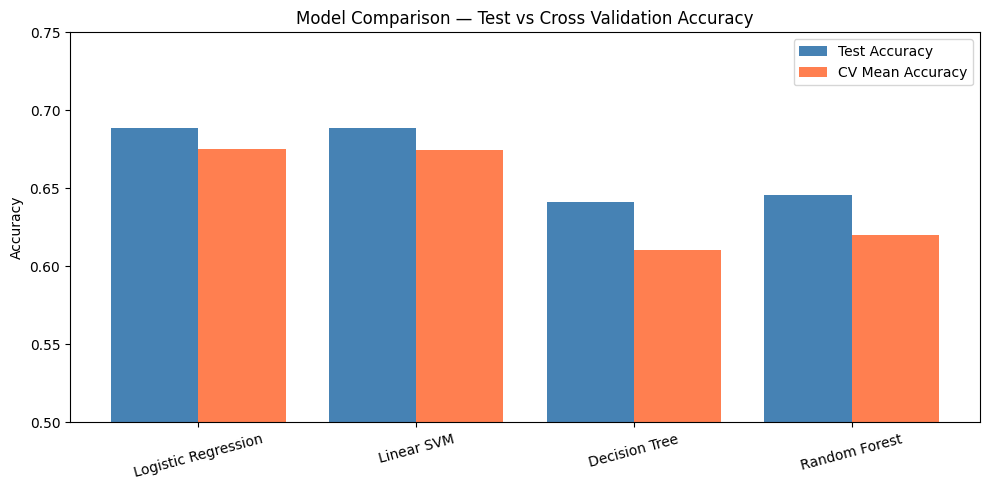

In [4]:
# Cell 3 - Train all models
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Linear SVM': CalibratedClassifierCV(LinearSVC(random_state=42, max_iter=1000)),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42)
}

results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    cv_scores = cross_val_score(model, X_scaled, y, cv=5, scoring='accuracy')
    results.append({
        'Model': name,
        'Test Accuracy': acc,
        'CV Mean': cv_scores.mean(),
        'CV Std': cv_scores.std()
    })
    print(f"{name}: Test={acc:.1%}, CV={cv_scores.mean():.1%} (+/-{cv_scores.std():.1%})")

results_df = pd.DataFrame(results)

# Plot
plt.figure(figsize=(10, 5))
x = range(len(results_df))
plt.bar([i - 0.2 for i in x], results_df['Test Accuracy'], 
        width=0.4, label='Test Accuracy', color='steelblue')
plt.bar([i + 0.2 for i in x], results_df['CV Mean'], 
        width=0.4, label='CV Mean Accuracy', color='coral')
plt.xticks(list(x), results_df['Model'], rotation=15)
plt.ylabel('Accuracy')
plt.title('Model Comparison — Test vs Cross Validation Accuracy')
plt.legend()
plt.ylim(0.5, 0.75)
plt.tight_layout()
plt.show()

## 🤖 Model Comparison Results

| Model | Test Accuracy | CV Mean | CV Std |
|---|---|---|---|
| Logistic Regression | 68.9% | 67.5% | ±1.3% |
| Linear SVM | 68.9% | 67.5% | ±1.4% |
| Decision Tree | 64.1% | 61.1% | ±1.2% |
| Random Forest | 64.6% | 62.0% | ±1.1% |

### Surprising Finding — Simple beats Complex!
Logistic Regression and Linear SVM both outperform 
Decision Tree and Random Forest!

This is actually a well known pattern:
- When the decision boundary is roughly **linear**, 
  simple models work better
- Complex models like Random Forest can **overfit** 
  to noise in the training data
- The COMPAS dataset has a relatively linear relationship 
  between features and recidivism

### What each model does:
- **Logistic Regression** — finds a straight line/plane separating the classes
- **Linear SVM** — finds the line with the maximum margin between classes
- **Decision Tree** — splits data with yes/no questions
- **Random Forest** — combines 100 decision trees

### Key Takeaway:
Always start with simple models! If Logistic Regression 
works as well as Random Forest, use Logistic Regression — 
it's faster, simpler, and more interpretable.

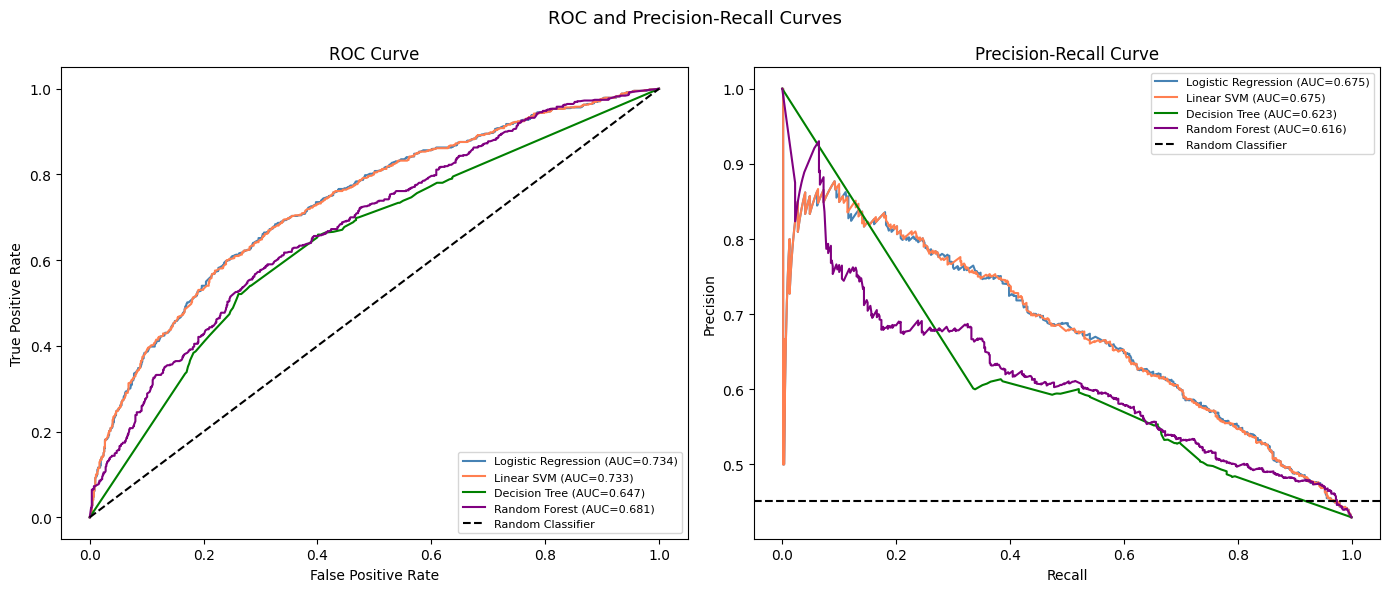

In [5]:
# Cell 4 - ROC and PR Curves
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

colors = ['steelblue', 'coral', 'green', 'purple']

for (name, model), color in zip(models.items(), colors):
    y_prob = model.predict_proba(X_test)[:, 1]
    
    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    axes[0].plot(fpr, tpr, color=color, 
                 label=f'{name} (AUC={roc_auc:.3f})')
    
    # PR Curve
    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    pr_auc = auc(recall, precision)
    axes[1].plot(recall, precision, color=color,
                 label=f'{name} (AUC={pr_auc:.3f})')

# ROC plot formatting
axes[0].plot([0, 1], [0, 1], 'k--', label='Random Classifier')
axes[0].set_title('ROC Curve')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend(loc='lower right', fontsize=8)

# PR plot formatting
axes[1].axhline(y=0.451, color='black', linestyle='--', 
                label='Random Classifier')
axes[1].set_title('Precision-Recall Curve')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].legend(loc='upper right', fontsize=8)

plt.suptitle('ROC and Precision-Recall Curves', fontsize=13)
plt.tight_layout()
plt.show()

## 📈 ROC and Precision-Recall Curves

### ROC Curve (left):
Shows tradeoff between True Positive Rate and False Positive Rate
at different thresholds.

| Model | ROC AUC |
|---|---|
| Logistic Regression | 0.734 |
| Linear SVM | 0.733 |
| Decision Tree | 0.647 |
| Random Forest | 0.681 |

- **AUC = 1.0** — perfect model
- **AUC = 0.5** — random guessing (dashed line)
- **AUC = 0.734** — Logistic Regression is best

### PR Curve (right):
Shows tradeoff between Precision and Recall.
More useful when classes are imbalanced.

| Model | PR AUC |
|---|---|
| Logistic Regression | 0.675 |
| Linear SVM | 0.675 |
| Decision Tree | 0.623 |
| Random Forest | 0.616 |

### Plain English:
**ROC AUC** answers: "How well can the model rank high risk 
cases above low risk cases?"

**PR AUC** answers: "When the model flags someone as high risk, 
how often is it right? And how many actual high risk cases does it catch?"

### Key Finding:
Logistic Regression wins on both curves — confirming it is 
the best model for this dataset despite being the simplest!

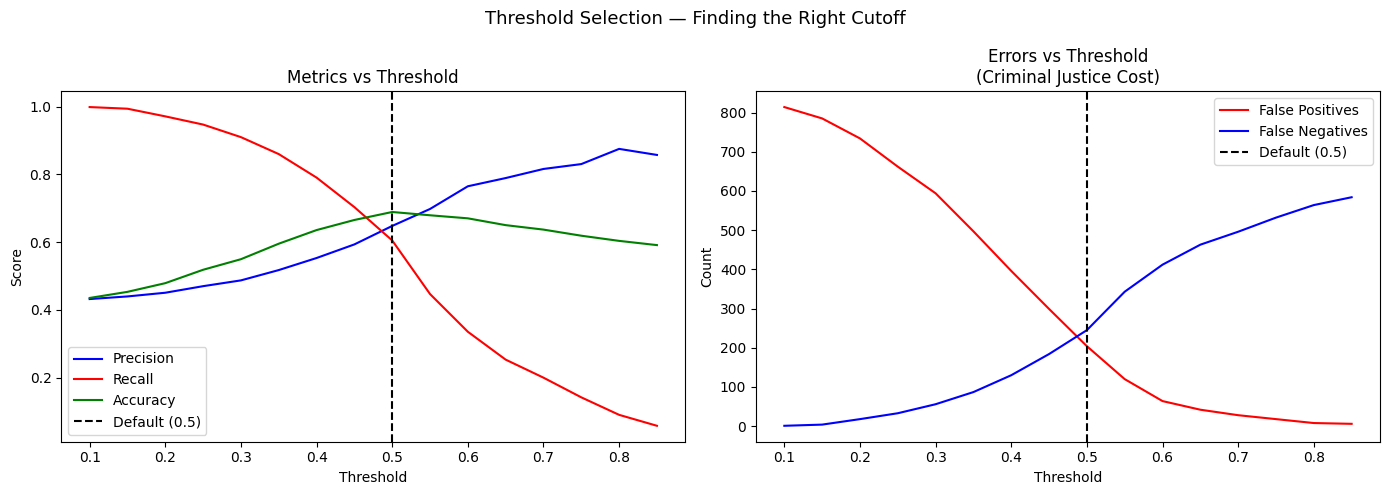

 Threshold  Accuracy  Precision   Recall  False Positives  False Negatives
      0.10  0.435204   0.431961 0.998387              814                1
      0.15  0.453222   0.439686 0.993548              785                4
      0.20  0.478863   0.450599 0.970968              734               18
      0.25  0.518365   0.469976 0.946774              662               33
      0.30  0.549550   0.487047 0.909677              594               56
      0.35  0.595288   0.517476 0.859677              497               87
      0.40  0.635482   0.553047 0.790323              396              130
      0.45  0.665281   0.593197 0.703226              299              184
      0.50  0.688843   0.647668 0.604839              204              245
      0.55  0.679141   0.697733 0.446774              120              343
      0.60  0.670132   0.764706 0.335484               64              412
      0.65  0.650035   0.788945 0.253226               42              463
      0.70  0.636868   0.

In [6]:
# Cell 5 - Threshold Selection
# Use Logistic Regression as best model
best_model = models['Logistic Regression']
y_prob = best_model.predict_proba(X_test)[:, 1]

thresholds = np.arange(0.1, 0.9, 0.05)
results_thresh = []

for thresh in thresholds:
    y_pred_thresh = (y_prob >= thresh).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_thresh).ravel()
    
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
    accuracy = (tp + tn) / len(y_test)
    
    results_thresh.append({
        'Threshold': thresh,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'False Positive Rate': fpr,
        'False Negatives': fn,
        'False Positives': fp
    })

thresh_df = pd.DataFrame(results_thresh)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(thresh_df['Threshold'], thresh_df['Precision'], 
             'b-', label='Precision')
axes[0].plot(thresh_df['Threshold'], thresh_df['Recall'], 
             'r-', label='Recall')
axes[0].plot(thresh_df['Threshold'], thresh_df['Accuracy'], 
             'g-', label='Accuracy')
axes[0].axvline(x=0.5, color='black', linestyle='--', label='Default (0.5)')
axes[0].set_title('Metrics vs Threshold')
axes[0].set_xlabel('Threshold')
axes[0].set_ylabel('Score')
axes[0].legend()

axes[1].plot(thresh_df['Threshold'], thresh_df['False Positives'], 
             'r-', label='False Positives')
axes[1].plot(thresh_df['Threshold'], thresh_df['False Negatives'], 
             'b-', label='False Negatives')
axes[1].axvline(x=0.5, color='black', linestyle='--', label='Default (0.5)')
axes[1].set_title('Errors vs Threshold\n(Criminal Justice Cost)')
axes[1].set_xlabel('Threshold')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.suptitle('Threshold Selection — Finding the Right Cutoff', fontsize=13)
plt.tight_layout()
plt.show()

print(thresh_df[['Threshold', 'Accuracy', 'Precision', 
                  'Recall', 'False Positives', 'False Negatives']].to_string(index=False))

## ⚖️ Threshold Selection — The Most Important Decision

### What is a Threshold?
By default classifiers predict "HIGH RISK" if probability >= 0.5.
But 0.5 is just a default — we can change it based on our priorities!

### Left Chart — Metrics vs Threshold:
- **Low threshold (0.1)** — catches almost everyone (Recall=99.8%) 
  but precision is terrible (43%)
- **High threshold (0.85)** — very precise (86%) but misses most 
  cases (Recall=6%)
- **Default (0.5)** — balanced but not necessarily best

### Right Chart — Errors vs Threshold (Criminal Justice):
- **Low threshold** — many False Positives (814!) few False Negatives (1)
- **High threshold** — few False Positives (6) many False Negatives (584!)
- Lines cross around threshold=0.5

### Which threshold should we use in criminal justice?

This is NOT a technical question — it is a **policy and ethical question**:

**If we lower threshold to 0.3:**
- Recall = 91% — catch 91% of people who will reoffend
- False Positives = 594 — 594 innocent people wrongly labeled high risk
- Use when: public safety is the priority

**If we raise threshold to 0.7:**
- Precision = 82% — when we flag someone we're usually right
- False Negatives = 496 — miss 496 people who will reoffend
- Use when: avoiding wrongful high risk labels is the priority

**Default threshold 0.5:**
- Balanced — 204 false positives, 245 false negatives
- Neither strongly prioritizes safety nor fairness

### The Fundamental Tension:
Reducing false positives (protecting innocent people) 
ALWAYS increases false negatives (missing real risks) 
and vice versa. There is no threshold that eliminates both.

This is why threshold selection must involve:
- Policymakers
- Legal experts  
- Affected communities
- NOT just data scientists